In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/1
    print("準備完了！このまま下のセルを実行できます。")

# 第1章 深層学習革命 (The Deep Learning Revolution)
## 1.2 チュートリアル例題：多項式曲線当てはめ (A Tutorial Example: Polynomial Curve Fitting)

機械学習の多くの基本概念（汎化、過学習、モデル複雑度、正則化、交差検証）は、単純な1変数の曲線当てはめ（Curve Fitting）問題を通じて直感的かつ厳密に理解することができます。
本ノートブックでは、Bishop & Bishop (2024) 第1章 1.2節に基づき、正弦波データに対する多項式回帰モデルを構築し、過学習の発生メカニズムとそれを制御する正則化の数理をステップ・バイ・ステップで実装・検証します。

### 目次
1. **1.2.1 人工データ生成 (Synthetic data)**: $\sin(2\pi x)$ と観測ノイズ (Figure 1.4)
2. **1.2.2 線形モデル (Linear models)**: パラメータ線形性の定義 (式 1.1)
3. **1.2.3 誤差関数 (Error function)**: 二乗和誤差と正規方程式の厳密導出 (式 1.2, Figure 1.5)
4. **1.2.4 モデルの複雑さ (Model complexity)**: 次数 $M$ の影響、$E_{\mathrm{RMS}}$、データ数効果 (式 1.3, Figure 1.6 - 1.8, Table 1.1)
5. **1.2.5 正則化 (Regularization)**: 荷重減衰 (Weight Decay) の数理と係数抑制 (式 1.4, Figure 1.9 - 1.10, Table 1.2)
6. **1.2.6 モデル選択 (Model selection)**: ホールドアウト法と $S$ 分割交差検証 (Figure 1.11)


In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common.plot_utils import setup_style, save_plot
from common.polynomial import (
    PolynomialFeatures,
    PolynomialRegression,
    generate_synthetic_data,
    k_fold_cross_validation
)

setup_style()
print("環境セットアップ完了")


環境セットアップ完了


---
### 1.2.1 人工データ生成 (Synthetic Data)

#### 真の規則性と観測ノイズ
現実世界のデータセットは、私たちが学習したい「背後にある規則性（Underlying Regularity）」と、未観測の要因や本質的なランダム性による「観測ノイズ（Observation Noise）」の合成として観測されます。
ここでは、真の生成関数を正弦波 $\sin(2\pi x)$ とし、これにガウス分布 $\mathcal{N}(0, \sigma^2)$ に従う乱数ノイズを加えた $N=10$ 点の訓練データを生成します：
$$t_n = \sin(2\pi x_n) + \epsilon_n, \quad \epsilon_n \sim \mathcal{N}(0, \sigma^2)$$

入力 $x_n$ は区間 $[0, 1]$ 内に等間隔に配置されます。機械学習の目標は、緑色の真の曲線を知ることなく、ノイズを含む青い観測点集合のみから、未知の入力 $\hat{x}$ に対する目標値 $\hat{t}$ を正確に予測すること（**汎化 Generalization**）です。


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 12479

Font 'default' does not have a glyph for '\u306e' [U+306e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u95a2' [U+95a2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u8a13' [U+8a13], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u8a13' [U+8a13], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7df4' [U+7df4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30c7' [U+30c7], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30fc' [U+30fc], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30bf' [U+30bf], substituting with a dummy symbol.


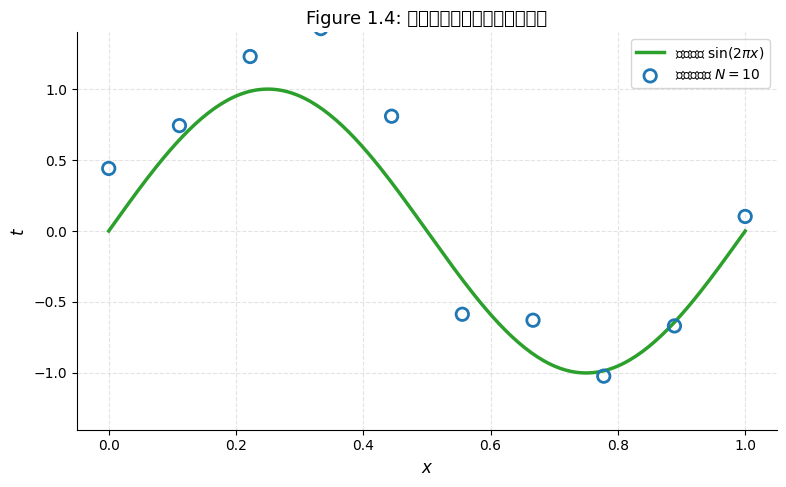

In [2]:
# Figure 1.4 再現: N=10 の訓練データと真の生成曲線 sin(2*pi*x)
np.random.seed(0)
N = 10
x_train, t_train = generate_synthetic_data(n_samples=N, noise_std=0.25, random_state=0)

# 真の曲線 (描画用高密度点)
x_dense = np.linspace(0.0, 1.0, 200)
t_true = np.sin(2.0 * np.pi * x_dense)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_dense, t_true, color='#2ca02c', lw=2.5, label='真の関数 $\sin(2\pi x)$')
ax.scatter(x_train, t_train, facecolors='none', edgecolors='#1f77b4', s=80, lw=2.0, zorder=5, label='訓練データ $N=10$')

ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.set_title('Figure 1.4: 訓練データ点と真の生成関数')
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-1.4, 1.4])
ax.legend(loc='upper right')

save_plot(fig, 'result/fig1_04_synthetic_data.png')
plt.show()


---
### 1.2.2 線形モデル (Linear Models)

#### 多項式関数形 (式 1.1)
データに曲線を当てはめるため、以下の $M$ 次多項式関数を考えます：
$$y(x, \mathbf{w}) = w_0 + w_1 x + w_2 x^2 + \dots + w_M x^M = \sum_{j=0}^M w_j x^j \tag{1.1}$$

ここで、$M$ は多項式の次数（Order）、$\mathbf{w} = (w_0, w_1, \dots, w_M)^T$ は多項式係数ベクトルです。

> [!IMPORTANT]
> **パラメータ線形性の重要性**:
> 多項式関数 $y(x, \mathbf{w})$ は入力変数 $x$ に対しては非線形関数ですが、**未知の係数ベクトル $\mathbf{w}$ に対しては線形（一次式）**です。
> このようにパラメータに関して線形であるモデルを**線形モデル（Linear Models）**と呼び、解析的に大域的最適解を一意に導出できる極めて優れた性質を持ちます（第4章で詳述）。


---
### 1.2.3 誤差関数 (Error Function) と正規方程式の厳密導出

#### 二乗和誤差 (式 1.2)
モデルの予測値 $y(x_n, \mathbf{w})$ と訓練目標値 $t_n$ のズレを評価するため、**二乗和誤差（Sum-of-Squares Error）**を定義します：
$$E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \{y(x_n, \mathbf{w}) - t_n\}^2 \tag{1.2}$$

係数 $\frac{1}{2}$ は、微分した際に生じる $2$ を相殺するための便宜的な定数です。
幾何学的には、各データ点における縦方向（垂直方向）の残差二乗の総和（の半分）を表します（Figure 1.5）。


/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 20055 (\N{CJK UNIFIED IDEOGRAPH-4E57}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 35492 (\N{CJK UNIFIED IDEOGRAPH-8AA4}) missing from font(s) DejaVu Sans.
  fig_or_plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
/home/student/Documents/GitHub/my_DeepLearning/common/plot_utils.py:31: UserWarning: Glyph 24046 (\N

Font 'default' does not have a glyph for '\u30c7' [U+30c7], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30eb' [U+30eb], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u66f2' [U+66f2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7dda' [U+7dda], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u7dda' [U+7dda], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30c7' [U+30c7], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30fc' [U+30fc], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30bf' [U+30bf], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u70b9' [U+70b9], substituting with a dummy symbol.


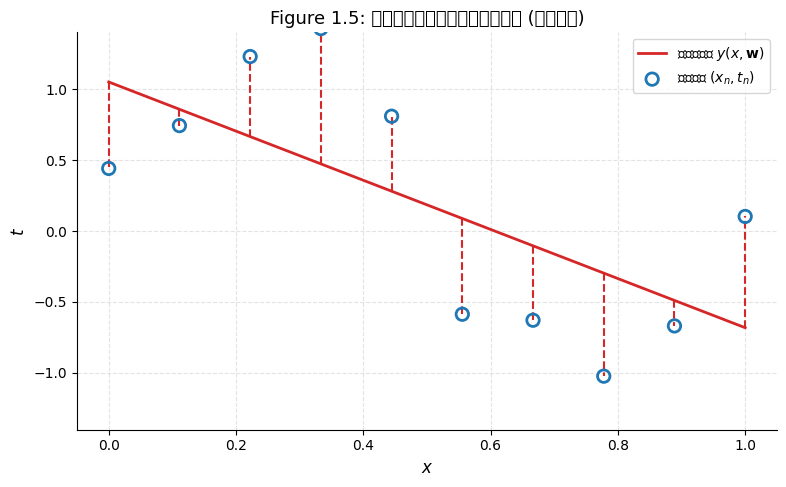

In [3]:
# Figure 1.5 再現: 二乗和誤差の幾何学的解釈 (残差の垂直二乗距離)
# 次数 M=1 の単純な直線回帰モデルで誤差を可視化
model_m1 = PolynomialRegression(degree=1).fit(x_train, t_train)
y_m1 = model_m1.predict(x_dense)
y_train_pred = model_m1.predict(x_train)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_dense, y_m1, color='#d62728', lw=2.0, label='モデル曲線 $y(x, \mathbf{w})$')
ax.scatter(x_train, t_train, facecolors='none', edgecolors='#1f77b4', s=80, lw=2.0, zorder=5, label='データ点 $(x_n, t_n)$')

# 垂直な残差破線を描画
for n in range(N):
    ax.plot([x_train[n], x_train[n]], [y_train_pred[n], t_train[n]], color='#d62728', linestyle='--', lw=1.5)

ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.set_title('Figure 1.5: 二乗和誤差関数の幾何学的解釈 (垂直残差)')
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-1.4, 1.4])
ax.legend(loc='upper right')

save_plot(fig, 'result/fig1_05_error_function.png')
plt.show()


#### 正規方程式 (Normal Equations) の手計算ステップ導出
誤差関数 $E(\mathbf{w})$ は $\mathbf{w}$ に関する下に凸の2次関数であるため、大域的最小値において係数 $w_i$ に関する偏微分が $0$ になります：
$$\frac{\partial E}{\partial w_i} = 0 \quad (i = 0, 1, \dots, M)$$

1. 合成関数の微分（微積分の連鎖律）を適用：
   $$\frac{\partial E}{\partial w_i} = \sum_{n=1}^N \{y(x_n, \mathbf{w}) - t_n\} \frac{\partial y(x_n, \mathbf{w})}{\partial w_i}$$
2. 式(1.1)より $\frac{\partial y(x_n, \mathbf{w})}{\partial w_i} = x_n^i$ であるため：
   $$\sum_{n=1}^N \left( \sum_{j=0}^M w_j x_n^j - t_n \right) x_n^i = 0$$
3. 展開して整理：
   $$\sum_{j=0}^M \left( \sum_{n=1}^N x_n^{i+j} \right) w_j = \sum_{n=1}^N t_n x_n^i \quad (i = 0, 1, \dots, M)$$

#### 行列形式 (Matrix Formulation)
計画行列（Design Matrix）$\mathbf{\Phi} \in \mathbb{R}^{N \times (M+1)}$ を次のように定義します：
$$\mathbf{\Phi} = \begin{pmatrix}
1 & x_1 & x_1^2 & \dots & x_1^M \\
1 & x_2 & x_2^2 & \dots & x_2^M \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_N & x_N^2 & \dots & x_N^M
\end{pmatrix}, \quad \mathbf{t} = \begin{pmatrix} t_1 \\ t_2 \\ \vdots \\ t_N \end{pmatrix}$$

これにより、連立方程式は有名な**正規方程式（Normal Equations）**として美しく記述されます：
$$\mathbf{\Phi}^T \mathbf{\Phi} \mathbf{w} = \mathbf{\Phi}^T \mathbf{t}$$
$\mathbf{\Phi}^T \mathbf{\Phi}$ が正則（逆行列が存在する）である場合、解析的最尤解は次のように一意に求まります：
$$\mathbf{w}^* = (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{t}$$


---
### 1.2.4 モデルの複雑さ (Model Complexity)

#### 多項式次数 $M$ のフィッティング比較 (Figure 1.6)
多項式の次数 $M$ はモデルの自由度（パラメータ数 $M+1$）を決定します。
以下のセルで $M=0, 1, 3, 9$ のフィッティング結果を比較します：
- **$M=0$ (定数関数)**: 表現力不足によりデータの特徴を捉えられない（**過小適合 Under-fitting**）。
- **$M=1$ (一次直線)**: 同様に過小適合。
- **$M=3$ (三次曲線)**: 真の関数 $\sin(2\pi x)$ の形状を良好に近似（**優れた汎化 Generalization**）。
- **$M=9$ (九次多項式)**: 10個の訓練データを完全に通過するが、点と点の間で激しく振動（**過学習 Over-fitting**）。


Font 'default' does not have a glyph for '\u771f' [U+771f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u306e' [U+306e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u95a2' [U+95a2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e88' [U+4e88], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u6e2c' [U+6e2c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u591a' [U+591a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9805' [U+9805], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5f0f' [U+5f0f], substituting with a dummy symbol.


Figure saved successfully to: result/fig1_06_polynomial_fitting.png


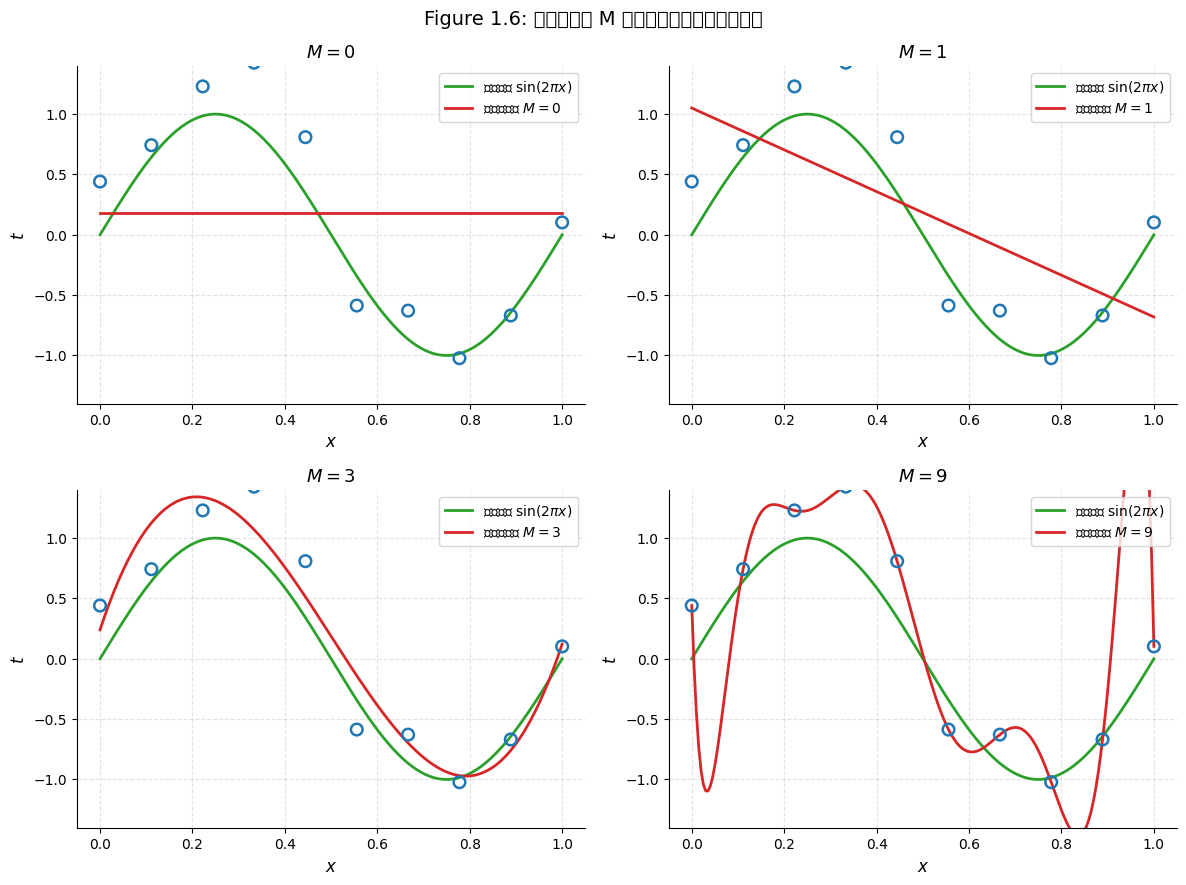

In [4]:
# Figure 1.6 再現: M = 0, 1, 3, 9 に対する多項式フィッティングの比較
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
degrees = [0, 1, 3, 9]

models = {}
for idx, M in enumerate(degrees):
    ax = axes[idx // 2, idx % 2]
    model = PolynomialRegression(degree=M).fit(x_train, t_train)
    models[M] = model
    
    y_pred = model.predict(x_dense)
    ax.plot(x_dense, t_true, color='#2ca02c', lw=2.0, label='真の関数 $\sin(2\pi x)$')
    ax.plot(x_dense, y_pred, color='#d62728', lw=2.0, label=f'予測多項式 $M={M}$')
    ax.scatter(x_train, t_train, facecolors='none', edgecolors='#1f77b4', s=70, lw=1.8, zorder=5)
    
    ax.set_title(f"$M = {M}$")
    ax.set_xlabel('$x$')
    ax.set_ylabel('$t$')
    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-1.4, 1.4])
    ax.legend(loc='upper right')

fig.suptitle("Figure 1.6: 異なる次数 M による多項式当てはめ結果", fontsize=14)
save_plot(fig, 'result/fig1_06_polynomial_fitting.png')
plt.show()


#### 平方根平均二乗誤差 (Root-Mean-Square Error: $E_{\mathrm{RMS}}$)
異なるデータサイズや次数を公平に比較するため、**平方根平均二乗誤差 $E_{\mathrm{RMS}}$**（式 1.3）を定義します：
$$E_{\mathrm{RMS}} = \sqrt{\frac{2 E(\mathbf{w}^*)}{N}} = \sqrt{\frac{1}{N} \sum_{n=1}^N \{y(x_n, \mathbf{w}^*) - t_n\}^2} \tag{1.3}$$

- $N$ で割ることで、データ数の異なるデータセット間で誤差の規模を統一します。
- 平方根をとることで、誤差の単位を元の目的変数 $t$ と同じスケールに戻します。

独立に生成したテストセット（$N_{\mathrm{test}} = 100$ 点）を用いて、$M=0$ から $9$ までの訓練誤差とテスト誤差をプロットします（Figure 1.7）。


Font 'default' does not have a glyph for '\u591a' [U+591a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9805' [U+9805], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5f0f' [U+5f0f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u306e' [U+306e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6b21' [U+6b21], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u5f0f' [U+5f0f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u306e' [U+306e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6b21' [U+6b21], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


Figure saved successfully to: result/fig1_07_rmse_vs_order.png


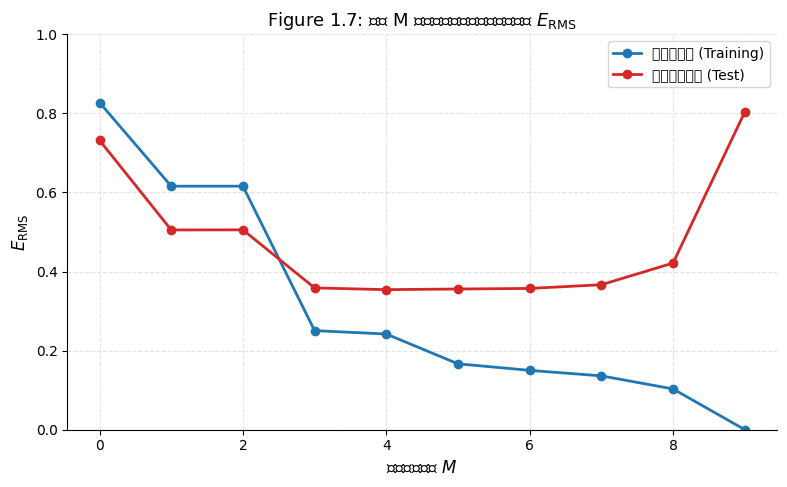

In [5]:
# Figure 1.7 再現: 訓練誤差とテスト誤差の次数 M に対する挙動
np.random.seed(1)
x_test, t_test = generate_synthetic_data(n_samples=100, noise_std=0.25, random_state=42)

all_degrees = list(range(10))
train_errors = []
test_errors = []

for M in all_degrees:
    m = PolynomialRegression(degree=M).fit(x_train, t_train)
    train_errors.append(m.rmse(x_train, t_train))
    test_errors.append(m.rmse(x_test, t_test))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(all_degrees, train_errors, marker='o', color='#1f77b4', lw=2.0, label='訓練データ (Training)')
ax.plot(all_degrees, test_errors, marker='o', color='#d62728', lw=2.0, label='テストデータ (Test)')

ax.set_xlabel('多項式の次数 $M$')
ax.set_ylabel('$E_{\mathrm{RMS}}$')
ax.set_title('Figure 1.7: 次数 M に対する平方根平均二乗誤差 $E_{\mathrm{RMS}}$')
ax.set_ylim([0.0, 1.0])
ax.legend(loc='upper right')

save_plot(fig, 'result/fig1_07_rmse_vs_order.png')
plt.show()


#### 係数の巨大化現象 (Table 1.1)
なぜ $M=9$ のモデルは激しく振動してしまうのでしょうか？
各次数で学習された係数ベクトル $\mathbf{w}^*$ の数値を表にまとめて確認します（Table 1.1）。


In [6]:
# Table 1.1 再現: 各次数 M における最適パラメータ w* の比較
table_data = {}
for M in [0, 1, 3, 9]:
    w = models[M].weights_
    # 長さを揃えるため9までNaNパディング
    w_padded = list(w) + [np.nan] * (10 - len(w))
    table_data[f"M = {M}"] = [f"{val:+.2f}" if not np.isnan(val) else "" for val in w_padded]

df_table_1_1 = pd.DataFrame(table_data, index=[f"w_{j}" for j in range(10)])
print("=== Table 1.1: 最適重み係数 w* の比較 ===")
display(df_table_1_1)


=== Table 1.1: 最適重み係数 w* の比較 ===


,M = 0,M = 1,M = 3,M = 9
w_0,+0.18,+1.05,+0.24,+0.44
w_1,,-1.73,+11.58,-114.12
w_2,,,-35.03,+2769.55
w_3,,,+23.34,-25857.22
w_4,,,,+126920.86
w_5,,,,-361596.77
w_6,,,,+616424.26
w_7,,,,-618746.53
w_8,,,,+336839.50
w_9,,,,-76639.87


$M$ が大きくなると、**係数の絶対値が急激に巨大化（正と負の数十万という巨大な値が互いに打ち消し合う）**していることがわかります。
これは、モデルがわずか10個のノイズ付きデータ点に無理やりフィッティングしようとした結果、急激な勾配を作り出しているためです。

#### データセットサイズと過学習の関係 (Figure 1.8)
過学習は「モデルの自由度」と「データ点数」の相対的バランスによって決まります。
たとえ複雑なモデル（$M=9$）であっても、**データ点数を $N=15$ や $N=100$ に増やすと、過学習の問題は劇的に緩和されます**（Figure 1.8）。


Font 'default' does not have a glyph for '\u771f' [U+771f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u306e' [U+306e], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u95a2' [U+95a2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e88' [U+4e88], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u6e2c' [U+6e2c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u591a' [U+591a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9805' [U+9805], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5f0f' [U+5f0f], substituting with a dummy symbol.


Figure saved successfully to: result/fig1_08_dataset_size_effect.png


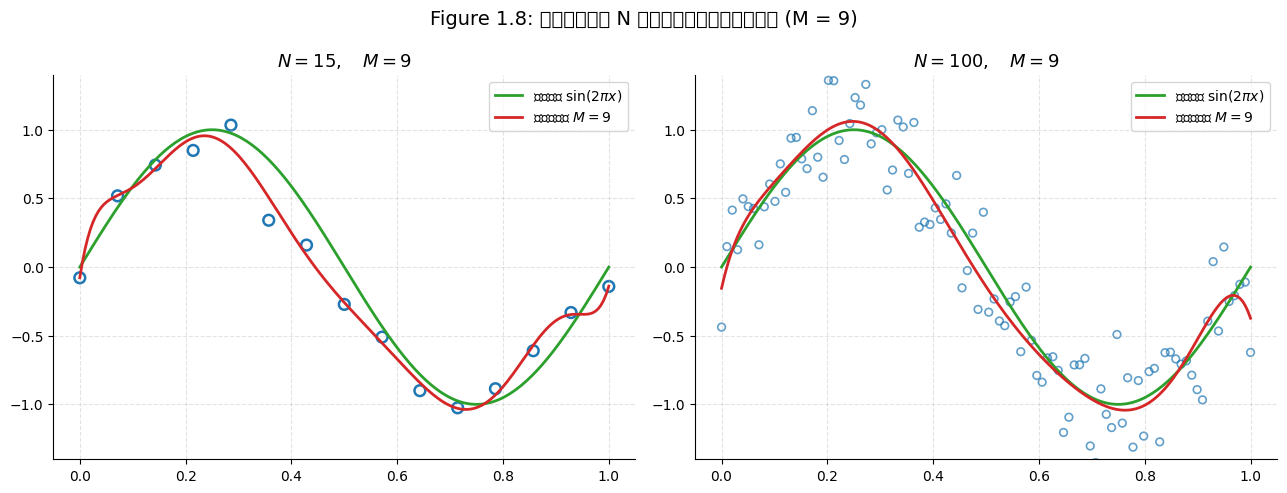

In [7]:
# Figure 1.8 再現: データ数の増加 (N=15, N=100) による過学習の抑制効果 (M=9)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# N = 15
x_15, t_15 = generate_synthetic_data(n_samples=15, noise_std=0.25, random_state=15)
m_15 = PolynomialRegression(degree=9).fit(x_15, t_15)
ax1.plot(x_dense, t_true, color='#2ca02c', lw=2.0, label='真の関数 $\sin(2\pi x)$')
ax1.plot(x_dense, m_15.predict(x_dense), color='#d62728', lw=2.0, label='予測多項式 $M=9$')
ax1.scatter(x_15, t_15, facecolors='none', edgecolors='#1f77b4', s=60, lw=1.8)
ax1.set_title("$N = 15, \quad M = 9$")
ax1.set_xlim([-0.05, 1.05])
ax1.set_ylim([-1.4, 1.4])
ax1.legend(loc='upper right')

# N = 100
x_100, t_100 = generate_synthetic_data(n_samples=100, noise_std=0.25, random_state=100)
m_100 = PolynomialRegression(degree=9).fit(x_100, t_100)
ax2.plot(x_dense, t_true, color='#2ca02c', lw=2.0, label='真の関数 $\sin(2\pi x)$')
ax2.plot(x_dense, m_100.predict(x_dense), color='#d62728', lw=2.0, label='予測多項式 $M=9$')
ax2.scatter(x_100, t_100, facecolors='none', edgecolors='#1f77b4', s=30, lw=1.2, alpha=0.7)
ax2.set_title("$N = 100, \quad M = 9$")
ax2.set_xlim([-0.05, 1.05])
ax2.set_ylim([-1.4, 1.4])
ax2.legend(loc='upper right')

fig.suptitle("Figure 1.8: データサイズ N の増大に伴う過学習の解消 (M = 9)", fontsize=14)
save_plot(fig, 'result/fig1_08_dataset_size_effect.png')
plt.show()


---
### 1.2.5 正則化 (Regularization: Weight Decay)

#### 荷重減衰の数理 (式 1.4)
データ数が限られている場合、係数の巨大化を直接抑制することで過学習を防ぐ技術が**正則化（Regularization）**です。
統計学では**リッジ回帰（Ridge Regression）**、機械学習・深層学習の文脈では**荷重減衰（Weight Decay）**と呼ばれます。
誤差関数にパラメータの二乗ノルムペナルティ項を追加します：
$$\tilde{E}(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \{y(x_n, \mathbf{w}) - t_n\}^2 + \frac{\lambda}{2} \|\mathbf{w}\|^2 \tag{1.4}$$

ここで、$\|\mathbf{w}\|^2 \equiv \mathbf{w}^T \mathbf{w} = w_0^2 + w_1^2 + \dots + w_M^2$ であり、$\lambda$ は正則化の強さを制御するハイパーパラメータです。

#### 正則化付き正規方程式の導出
修正誤差関数 $\tilde{E}(\mathbf{w})$ を $\mathbf{w}$ で勾配計算すると：
$$\nabla_{\mathbf{w}} \tilde{E} = \mathbf{\Phi}^T (\mathbf{\Phi}\mathbf{w} - \mathbf{t}) + \lambda \mathbf{w} = \mathbf{0}$$
$$\implies (\mathbf{\Phi}^T \mathbf{\Phi} + \lambda \mathbf{I}) \mathbf{w} = \mathbf{\Phi}^T \mathbf{t}$$
対角行列 $\lambda \mathbf{I}$ が加わることで、$\mathbf{\Phi}^T \mathbf{\Phi}$ が特異（非正則）になりやすい高次多項式でも、逆行列が常に安定して計算可能になるという数値計算上の大きなメリットもあります：
$$\mathbf{w}^* = (\mathbf{\Phi}^T \mathbf{\Phi} + \lambda \mathbf{I})^{-1} \mathbf{\Phi}^T \mathbf{t}$$


Font 'default' does not have a glyph for '\u9069' [U+9069], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5207' [U+5207], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u306a' [U+306a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6b63' [U+6b63], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5247' [U+5247], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u5316' [U+5316], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5c0f' [U+5c0f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u9069' [U+9069], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5408' [U+5408], substituting with a dummy symbol.


Figure saved successfully to: result/fig1_09_regularization_fitting.png


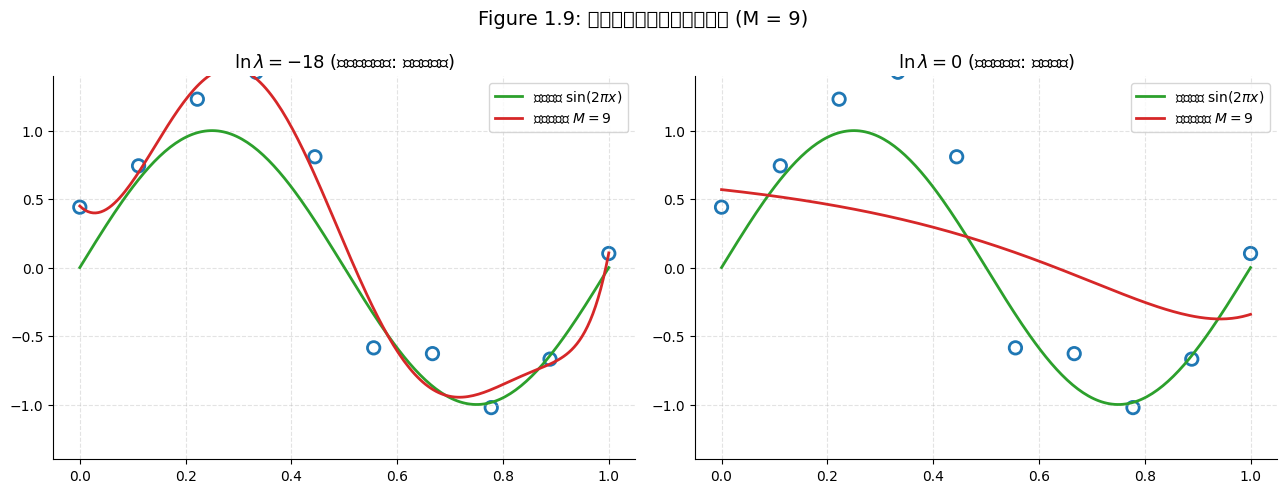

In [8]:
# Figure 1.9 再現: 正則化ハイパーパラメータ lambda の影響 (M = 9)
# ln(lambda) = -18 (適切な正則化) と ln(lambda) = 0 (強すぎる正則化)
lambda_good = np.exp(-18)
lambda_heavy = np.exp(0)

m_reg_good = PolynomialRegression(degree=9, l2_reg=lambda_good).fit(x_train, t_train)
m_reg_heavy = PolynomialRegression(degree=9, l2_reg=lambda_heavy).fit(x_train, t_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ln(lambda) = -18
ax1.plot(x_dense, t_true, color='#2ca02c', lw=2.0, label='真の関数 $\sin(2\pi x)$')
ax1.plot(x_dense, m_reg_good.predict(x_dense), color='#d62728', lw=2.0, label='予測多項式 $M=9$')
ax1.scatter(x_train, t_train, facecolors='none', edgecolors='#1f77b4', s=80, lw=2.0)
ax1.set_title("$\ln \lambda = -18$ (適切な正則化: 振動の消失)")
ax1.set_xlim([-0.05, 1.05])
ax1.set_ylim([-1.4, 1.4])
ax1.legend(loc='upper right')

# ln(lambda) = 0
ax2.plot(x_dense, t_true, color='#2ca02c', lw=2.0, label='真の関数 $\sin(2\pi x)$')
ax2.plot(x_dense, m_reg_heavy.predict(x_dense), color='#d62728', lw=2.0, label='予測多項式 $M=9$')
ax2.scatter(x_train, t_train, facecolors='none', edgecolors='#1f77b4', s=80, lw=2.0)
ax2.set_title("$\ln \lambda = 0$ (過剰正則化: 過小適合)")
ax2.set_xlim([-0.05, 1.05])
ax2.set_ylim([-1.4, 1.4])
ax2.legend(loc='upper right')

fig.suptitle("Figure 1.9: 正則化による過学習の制御 (M = 9)", fontsize=14)
save_plot(fig, 'result/fig1_09_regularization_fitting.png')
plt.show()


In [9]:
# Table 1.2 再現: 正則化パラメータ ln(lambda) によるパラメータ係数の抑制比較
m_unreg = models[9]

df_table_1_2 = pd.DataFrame({
    "ln(lambda) = -inf (無正則化)": [f"{w:+.2f}" for w in m_unreg.weights_],
    "ln(lambda) = -18 (最適正則化)": [f"{w:+.2f}" for w in m_reg_good.weights_],
    "ln(lambda) = 0 (過剰正則化)": [f"{w:+.2f}" for w in m_reg_heavy.weights_]
}, index=[f"w_{j}" for j in range(10)])

print("=== Table 1.2: 正則化による係数ベクトルの大きさの抑制 ===")
display(df_table_1_2)


=== Table 1.2: 正則化による係数ベクトルの大きさの抑制 ===


,ln(lambda) = -inf (無正則化),ln(lambda) = -18 (最適正則化),ln(lambda) = 0 (過剰正則化)
w_0,+0.44,+0.45,+0.57
w_1,-114.12,-3.76,-0.42
w_2,+2769.55,+75.07,-0.49
w_3,-25857.22,-195.13,-0.35
w_4,+126920.86,-2.13,-0.19
w_5,-361596.77,+294.19,-0.06
w_6,+616424.26,-6.59,+0.05
w_7,-618746.53,-226.93,+0.13
w_8,+336839.50,-40.32,+0.19
w_9,-76639.87,+105.27,+0.23


Font 'default' does not have a glyph for '\u6b63' [U+6b63], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5247' [U+5247], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5316' [U+5316], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30d1' [U+30d1], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u30e9' [U+30e9], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u4e8c' [U+4e8c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e57' [U+4e57], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u8aa4' [U+8aa4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5dee' [U+5dee], substituting with a dummy symbol.


Figure saved successfully to: result/fig1_10_rmse_vs_lambda.png


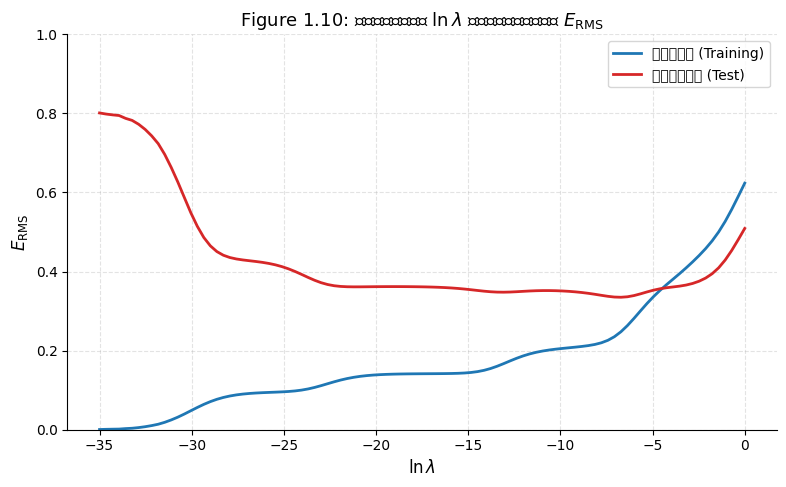

In [10]:
# Figure 1.10 再現: ln(lambda) に対する E_RMS の挙動
ln_lambdas = np.linspace(-35, 0, 100)
train_rms_list = []
test_rms_list = []

for ln_lam in ln_lambdas:
    lam = np.exp(ln_lam)
    m = PolynomialRegression(degree=9, l2_reg=lam).fit(x_train, t_train)
    train_rms_list.append(m.rmse(x_train, t_train))
    test_rms_list.append(m.rmse(x_test, t_test))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ln_lambdas, train_rms_list, color='#1f77b4', lw=2.0, label='訓練セット (Training)')
ax.plot(ln_lambdas, test_rms_list, color='#d62728', lw=2.0, label='テストセット (Test)')

ax.set_xlabel('$\ln \lambda$')
ax.set_ylabel('$E_{\mathrm{RMS}}$')
ax.set_title('Figure 1.10: 正則化パラメータ $\ln \lambda$ と平方根平均二乗誤差 $E_{\mathrm{RMS}}$')
ax.set_ylim([0.0, 1.0])
ax.legend(loc='upper right')

save_plot(fig, 'result/fig1_10_rmse_vs_lambda.png')
plt.show()


---
### 1.2.6 モデル選択 (Model Selection: Cross-Validation)

#### ハイパーパラメータ選定の課題
現実の機械学習では、最適な多項式次数 $M$ や正則化パラメータ $\lambda$ をあらかじめ知ることはできません。
これらをテストデータ上で選んでしまうと、テストデータに対する過学習（データリーク）が発生し、真の未知データに対する性能が測定できなくなります。

#### $S$ 分割交差検証 (S-fold Cross-Validation)
データ量が少ない場合に威力を発揮するのが **$S$ 分割交差検証（Figure 1.11）**です：
1. 利用可能な全データを $S$ 個の互いに素なグループ（Fold）に等分割する。
2. そのうち $S-1$ 個のグループ（全体の $(S-1)/S$ のデータ）を訓練に用い、残りの $1$ 個のグループを検証（Validation）に用いる。
3. 検証に用いるグループを順次交代させながら、計 $S$ 回の評価を行う。
4. $S$ 回の検証誤差の平均値をモデルの予測性能スコアとする。


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5272' [U+5272], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4ea4' [U+4ea4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5dee' [U+5dee], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u691c' [U+691c], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u9805' [U+9805], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5f0f' [U+5f0f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6b21' [U+6b21], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6570' [U+6570], substituting with a dummy symbol.


Figure saved successfully to: result/fig1_11_cross_validation.png


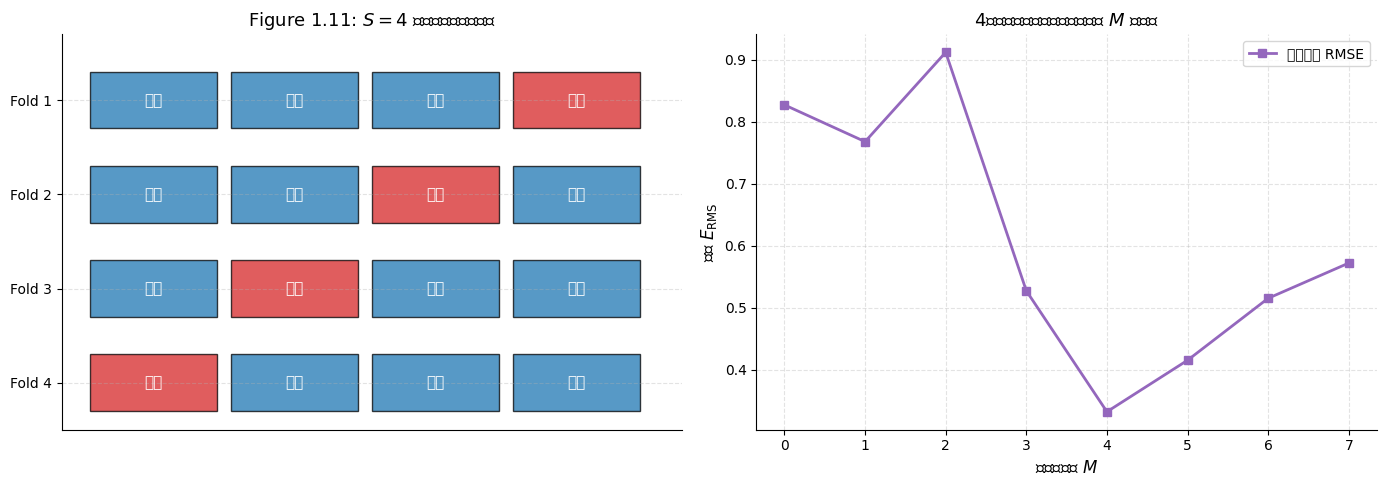

In [11]:
# Figure 1.11 再現: S 分割交差検証 (S = 4) の模式図と数値シミュレーション
fig, (ax_diag, ax_cv) = plt.subplots(1, 2, figsize=(14, 5))

# 左パネル: 4分割交差検証のダイアグラム
S = 4
for i in range(S):
    # 4つのブロックを描画
    for j in range(S):
        color = '#d62728' if j == (S - 1 - i) else '#1f77b4'
        text = '検証' if j == (S - 1 - i) else '訓練'
        rect = plt.Rectangle((j, S - 1 - i), 0.9, 0.6, facecolor=color, alpha=0.75, edgecolor='black')
        ax_diag.add_patch(rect)
        ax_diag.text(j + 0.45, S - 1 - i + 0.3, text, ha='center', va='center', color='white', fontweight='bold')

ax_diag.set_xlim([-0.2, S + 0.2])
ax_diag.set_ylim([-0.2, S])
ax_diag.set_yticks(np.arange(S) + 0.3)
ax_diag.set_yticklabels([f"Fold {S - k}" for k in range(S)])
ax_diag.set_xticks([])
ax_diag.set_title("Figure 1.11: $S=4$ 分割交差検証の構造")

# 右パネル: 交差検証による最適次数 M の探索
cv_scores = []
for M in range(8):
    res = k_fold_cross_validation(x_train, t_train, k=4, degree=M, l2_reg=1e-3, random_state=42)
    cv_scores.append(res['mean_val_rmse'])

ax_cv.plot(range(8), cv_scores, marker='s', color='#9467bd', lw=2.0, label='平均検証 RMSE')
ax_cv.set_xlabel('多項式次数 $M$')
ax_cv.set_ylabel('検証 $E_{\mathrm{RMS}}$')
ax_cv.set_title('4分割交差検証による最適次数 $M$ の選定')
ax_cv.legend()

save_plot(fig, 'result/fig1_11_cross_validation.png')
plt.show()


---
### まとめと第2章への展望

本ノートブックでは以下の重要原則を学びました：
1. **過学習の正体**: モデルの自由度（パラメータ数）がデータ数に対して過剰な場合、モデルはデータの背後にある普遍的法則ではなく「特定のノイズ」を暗記してしまう。
2. **正則化の効用**: 荷重減衰ペナルティ $\frac{\lambda}{2}\|\mathbf{w}\|^2$ を導入することで、係数の極端な巨大化を防ぎ、モデルの有効自由度を連続的に制御できる。
3. **データ規模の重要性**: 複雑なモデルであっても、データ数 $N$ を増やすことで過学習を根本的に解消できる（これが現代の深層学習が巨大データで成功した理由）。

しかし、ここで一つ根本的な疑問が生じます：
- 「なぜ二乗和誤差なのか？」「正則化項の $\frac{\lambda}{2}$ は数学的にどこから導かれるのか？」
- 「予測値の不確実性（Uncertainty）をどうやって定量評価するのか？」

これらの問いに厳密な解答を与えるのが、次の **第2章「確率の基礎 (Probabilities)」** です。
確率論（最尤推定とベイズ推論）を導入することで、二乗和誤差は「ガウスノイズの対数尤度最大化」、荷重減衰は「パラメータに対するガウス事前分布の導入（MAP推定）」として自然に統一されることを学びます。
